In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

def create_Apl_Ami_Heff_M2_matrices(r_vec, V_vec, Z, ell, deltaTau):
    Delta_r = r_vec[1] - r_vec[0]
    N = len(r_vec)
    
    D_lower = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_upper = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_diag = -2*np.ones(N, dtype=complex)/(Delta_r**2)
    D_11_corr = -2*(1 - (Z*Delta_r)/(12 - 10*Z*Delta_r))/(Delta_r**2)
    if ell == 0:
        D_diag[0] = D_11_corr
    D = get_sparseMatrix(D_lower, D_diag, D_upper)
    
    M_2_lower = -np.ones(N-1, dtype=complex)/6
    M_2_diag = -10*np.ones(N, dtype=complex)/6
    M_2_upper = -np.ones(N-1, dtype=complex)/6
    if ell == 0:
        M_2_diag[0] = -2*(1 + (Delta_r**2)*D_11_corr/12)
    M_2 = get_sparseMatrix(M_2_lower, M_2_diag, M_2_upper)
    
    V_matrix = sparse.spdiags([V_vec], [0], N, N)
    
    # Hamiltonian (effective)
    H_2 = D + M_2@V_matrix
    
    # CN A matrices
    A_pl = M_2 + 0.5j * deltaTau * H_2
    A_mi = M_2 - 0.5j * deltaTau * H_2
    return A_pl, A_mi, H_2, M_2

def get_sparseMatrix(upper, mid, lower):
    return sparse.diags([lower, mid, upper], offsets=[-1, 0, 1], format="csr")

def CN_propagation(A_pl, A_mi, psi, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)): # Iterate for imaginary time
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r)
    return psi

def calc_E_withNumerov(psi, H_2, M_2, r):
    return project(psi, H_2 @ psi, r)/project(psi, M_2 @ psi, r)


def get_diag(mat):
    return np.array([mat[i, i] for i in range(mat.shape[0])], dtype=complex)
def get_upper(mat):
    return np.array([mat[i-1, i] for i in range(1, mat.shape[0])], dtype=complex)
def get_lower(mat):
    return np.array([mat[i, i-1] for i in range(1, mat.shape[0])], dtype=complex)

def project(psi1, psi2, r_vec):
    return np.trapz(np.conj(psi1)*psi2, x=r_vec)


def normalize(psi, r_vec):
    return psi/np.sqrt(project(psi, psi, r_vec))

def thomas_algorithm(a, b, c, d):
    n = len(b)
    
    # Create copies of the input arrays to modify during elimination
    bp = np.copy(b).astype(complex) # diagonal copy
    dp = np.copy(d).astype(complex) # Right-hand side copy
    
    # Forward elimination
    for i in range(1, n):
        # Modify the coefficients in the sub-diagonal and right-hand side
        w = a[i-1] / bp[i-1]
        bp[i] = b[i] - w * c[i-1]
        dp[i] = d[i] - w * dp[i-1]
    
    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = dp[-1] / bp[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dp[i] - c[i] * x[i+1]) / bp[i]
    return x

Text(0.5, 1.0, 'Hydrogen wavefuctions - Comparing Coulomb and Softcore Potentials')

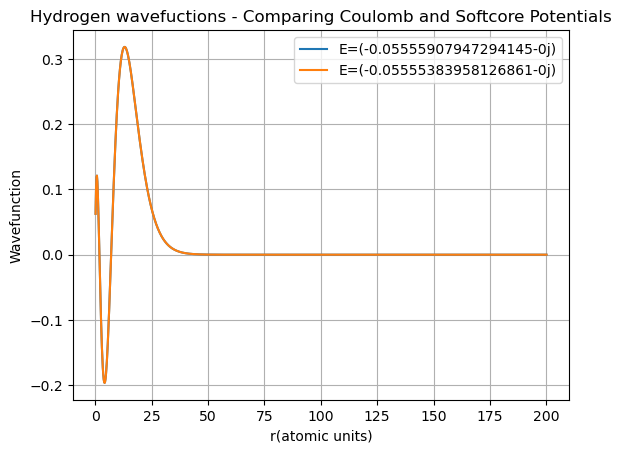

In [4]:
# Constants
Z = 1
Delta_r = 0.2
N = 1000
r_vec = np.linspace(Delta_r, N * Delta_r, N) 
ell = 0

# Coulomb and Softcore compared
# V(r) = -1/r
V_vec_coulomb = -1/r_vec

# Potential: V(r) = -1/sqrt(x2 + a2)
a = 0.00823974609375 # obtained in the previous program, accuracy up to 1e-6
V_vec_softcore = -1/np.sqrt(r_vec**2 + a**2)


def calculate_psi_and_E_based_on_potential(V_vec):
    # Constants
    # Z = 1
    # Delta_r = 0.2
    # N = 1000
    # r_vec = np.linspace(Delta_r, N * Delta_r, N) 
    # ell = 0

    # Potential: V(r) = -1/sqrt(x2 + a2)
    # a = 0.00823974609375 # obtained in the previous program, accuracy up to 1e-6
    # V_vec = -1/np.sqrt(r_vec**2 + a**2)

    # V_vec in argument
    
    # Imaginary time step (Δτ)
    delta = -0.9
    E_k = -0.0556
    Delta_tau = 2*delta/E_k
    imagDeltaTau = (-1j*Delta_tau)

    # Create matrices
    A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(r_vec, V_vec, Z, ell, imagDeltaTau)

    # Initial wavefunction (guessed)
    psi = np.random.random(N).astype(complex)
    psi = normalize(psi, r_vec)

    # Crank-Nicolson propagation
    psi = CN_propagation(A_pl, A_mi, psi, r_vec)
    E = calc_E_withNumerov(psi, H_2, M_2, r_vec)
    
    return psi, E

psi_coulomb, E_coulomb = calculate_psi_and_E_based_on_potential(V_vec_coulomb)
psi_softcore, E_softcore = calculate_psi_and_E_based_on_potential(V_vec_softcore)

plt.plot(r_vec, psi_coulomb, label=f"E={E_coulomb}")
plt.plot(r_vec, psi_softcore, label=f"E={E_softcore}")
plt.xlabel("r(atomic units)")
plt.grid()
plt.ylabel("Wavefunction")
plt.legend()
plt.title(f"Hydrogen wavefuctions - Comparing Coulomb and Softcore Potentials")

# # saving for further use
# np.save("psi0.npy", psi)
# np.save("r_vec.npy", r_vec)
